In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, accuracy_score,
                             f1_score, log_loss, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

DATA = Path.cwd()
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'figure.dpi': 120})
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 12)

## 1. Загрузка и проверка данных
Используем ежедневную статистику Capital Bikeshare в Вашингтоне за 2011–2012 годы.
Источник: [Bike Sharing in Washington D.C. Dataset](https://www.kaggle.com/datasets/marklvl/bike-sharing-dataset).
Файл day.csv скачан с Kaggle и сохранён без изменения исходных значений.
Одна строка соответствует дню. Цель cnt — общее число аренд за день.
Погода представлена нормированными температурой, влажностью и скоростью ветра.
Авторы исходного набора: H. Fanaee-T и J. Gama, «Event labeling combining ensemble
detectors and background knowledge», 2013, DOI: 10.1007/s13748-013-0040-3.

Проверяем полноту календаря, пропуски, дубликаты, диапазоны и целостность счётчиков.
Резкое падение спроса само по себе не является ошибкой: такие дни не удаляем.

In [2]:
raw = pd.read_csv(DATA / 'day.csv')
raw['dteday'] = pd.to_datetime(raw['dteday'], format='%Y-%m-%d')
raw = raw.sort_values('dteday').reset_index(drop=True)
assert len(raw) == 731
assert raw.isna().sum().sum() == 0
assert not raw.duplicated().any() and not raw['dteday'].duplicated().any()
assert raw['dteday'].diff().dropna().eq(pd.Timedelta(days=1)).all()
assert (raw['cnt'] > 0).all()
assert (raw['cnt'] == raw['casual'] + raw['registered']).all()
for col in ['cnt', 'casual', 'registered']:
    assert (raw[col] >= 0).all() and (raw[col] % 1 == 0).all()
for col in ['temp', 'atemp', 'hum', 'windspeed']:
    assert raw[col].between(0, 1).all()
for col in ['holiday', 'workingday', 'yr']:
    assert raw[col].isin([0, 1]).all()
assert raw['weekday'].between(0, 6).all()
assert raw['weathersit'].between(1, 4).all()
print(f'Строк: {len(raw)}, столбцов: {len(raw.columns)}.')
print(f'Период: {raw.dteday.min().date()} — {raw.dteday.max().date()}.')
print('Пропуски: 0; полные дубликаты: 0; повторные и пропущенные даты: 0.')
print(raw[['cnt', 'temp', 'hum', 'windspeed']].describe().round(3))

Строк: 731, столбцов: 16.
Период: 2011-01-01 — 2012-12-31.
Пропуски: 0; полные дубликаты: 0; повторные и пропущенные даты: 0.
            cnt     temp      hum  windspeed
count   731.000  731.000  731.000    731.000
mean   4504.349    0.495    0.628      0.190
std    1937.211    0.183    0.142      0.077
min      22.000    0.059    0.000      0.022
25%    3152.000    0.337    0.520      0.135
50%    4548.000    0.498    0.627      0.181
75%    5956.000    0.655    0.730      0.233
max    8714.000    0.862    0.972      0.507


## 2. Признаки и разделение по времени
Строим прогноз на один следующий день. Календарные признаки дня известны заранее.
Число аренд вчера и неделю назад, среднее за предыдущую неделю и вчерашняя погода
также доступны к моменту прогноза. Фактическую погоду прогнозируемого дня не используем.
casual и registered исключаем: их сумма равна целевой переменной и дала бы утечку.

Первые 7 дней используются как история для лагов. Остаётся 724 наблюдения.
Последние 20% выделяем в тест. Внутри первых 80% последние 25% служат валидацией
для выбора настроек и регрессионной модели. После выбора модели переобучаем
на всех первых 80%. Тест не участвует в выборе параметров и границы классов.

Тест оценивается последовательно: перед прогнозом следующего дня уже известно
фактическое число аренд за прошедший день. Это серия однодневных прогнозов,
а не прогноз всего тестового интервала из одной начальной точки.

In [3]:
frame = pd.DataFrame({'date': raw['dteday'], 'target': raw['cnt'].astype(float)})
frame['trend'] = (raw['dteday'] - raw['dteday'].iloc[0]).dt.days / 365.25
day_of_year = raw['dteday'].dt.dayofyear
day_of_week = raw['dteday'].dt.dayofweek
frame['year_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
frame['year_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
frame['week_sin'] = np.sin(2 * np.pi * day_of_week / 7)
frame['week_cos'] = np.cos(2 * np.pi * day_of_week / 7)
frame['holiday'] = raw['holiday']
frame['workingday'] = raw['workingday']
frame['rent_lag1'] = raw['cnt'].shift(1)
frame['rent_lag7'] = raw['cnt'].shift(7)
frame['rent_mean7'] = raw['cnt'].shift(1).rolling(7).mean()
for col in ['temp', 'hum', 'windspeed']:
    frame[f'{col}_lag1'] = raw[col].shift(1)
frame['bad_weather_lag1'] = (raw['weathersit'].shift(1) >= 3).astype(float)
frame = frame.iloc[7:].reset_index(drop=True)
assert not frame.isna().any().any()
features = frame.columns.drop(['date', 'target']).tolist()
n_train = int(len(frame) * 0.8)
n_fit = int(n_train * 0.75)
train = frame.iloc[:n_train].copy()
test = frame.iloc[n_train:].copy()
fit = train.iloc[:n_fit].copy()
validation = train.iloc[n_fit:].copy()
X_train, y_train = train[features], train['target'].to_numpy()
X_test, y_test = test[features], test['target'].to_numpy()
X_fit, y_fit = fit[features], fit['target'].to_numpy()
X_val, y_val = validation[features], validation['target'].to_numpy()
assert fit.date.max() < validation.date.min() < test.date.min()
for name, subset in [('Обучение для настройки', fit), ('Валидация', validation),
                     ('Полное обучение', train), ('Тест', test)]:
    print(f'{name}: {len(subset)} дней, {subset.date.min().date()} — {subset.date.max().date()}')
print('Признаки:', ', '.join(features))

Обучение для настройки: 434 дней, 2011-01-08 — 2012-03-16
Валидация: 145 дней, 2012-03-17 — 2012-08-08
Полное обучение: 579 дней, 2011-01-08 — 2012-08-08
Тест: 145 дней, 2012-08-09 — 2012-12-31
Признаки: trend, year_sin, year_cos, week_sin, week_cos, holiday, workingday, rent_lag1, rent_lag7, rent_mean7, temp_lag1, hum_lag1, windspeed_lag1, bad_weather_lag1


## 3. Множественная регрессия: МНК и SVR
МНК строит линейную зависимость y = c0 + c1*x1 + ... + cp*xp.
SVR с RBF-ядром позволяет учитывать нелинейные связи. Масштабирование признаков
и цели обучается только на соответствующей обучающей части.
Настройки SVR выбираем по RMSE на валидации. Лучшую регрессию также выбираем
по валидационной RMSE, до оценки теста. Отрицательные прогнозы числа аренд
ограничиваем нулём одинаково для обеих моделей; округление не используем.

In [4]:
def build_regression(name, C=10, gamma='scale'):
    if name == 'МНК':
        return make_pipeline(StandardScaler(), LinearRegression())
    return TransformedTargetRegressor(
        regressor=make_pipeline(StandardScaler(), SVR(kernel='rbf', C=C, gamma=gamma, epsilon=0.1)),
        transformer=StandardScaler())

def rental_prediction(model, x):
    return np.maximum(model.predict(x), 0)

selection = []
ols_val_model = build_regression('МНК').fit(X_fit, y_fit)
ols_val_pred = rental_prediction(ols_val_model, X_val)
selection.append({'Модель': 'МНК', 'C': np.nan, 'gamma': '-',
                  'RMSE валидации': np.sqrt(mean_squared_error(y_val, ols_val_pred))})
svr_candidates = []
for c in [1, 10, 100]:
    for gamma in ['scale', 0.01]:
        model = build_regression('SVR', c, gamma).fit(X_fit, y_fit)
        values = rental_prediction(model, X_val)
        score = np.sqrt(mean_squared_error(y_val, values))
        selection.append({'Модель': 'SVR', 'C': c, 'gamma': str(gamma), 'RMSE валидации': score})
        svr_candidates.append((score, c, gamma, values))
_, best_c, best_gamma, svr_val_pred = min(svr_candidates, key=lambda item: item[0])
validation_predictions = {'МНК': ols_val_pred, 'SVR': svr_val_pred}
best_reg_name = min(validation_predictions,
                    key=lambda name: mean_squared_error(y_val, validation_predictions[name]))
reg_models = {'МНК': build_regression('МНК').fit(X_train, y_train),
              'SVR': build_regression('SVR', best_c, best_gamma).fit(X_train, y_train)}
reg_predictions = {name: rental_prediction(model, X_test) for name, model in reg_models.items()}
print(pd.DataFrame(selection).sort_values('RMSE валидации').round(3).to_string(index=False))
print(f'Выбрана регрессия: {best_reg_name}. Настройки SVR: C={best_c}, gamma={best_gamma}.')

Модель     C gamma  RMSE валидации
   МНК   NaN     -        1067.039
   SVR  10.0  0.01        1267.827
   SVR   1.0  0.01        1384.623
   SVR 100.0  0.01        1501.458
   SVR  10.0 scale        1873.668
   SVR 100.0 scale        2018.248
   SVR   1.0 scale        2525.255
Выбрана регрессия: МНК. Настройки SVR: C=10, gamma=0.01.


## 4. Адекватность регрессии
Сравниваем фактические значения и прогнозы на одинаковых тестовых днях.
MAE и RMSE измеряются в арендах за день. MAPE выражается в процентах;
нулевых целевых значений нет, поэтому её знаменатель определён для всех дней.
MASE делит MAE на среднее абсолютное изменение между соседними днями обучения
(несезонный наивный прогноз, m=1). Значение MASE меньше 1 означает ошибку меньше
этого обучающего масштаба, но не гарантирует превосходства над наивным прогнозом на тесте.
Поэтому отдельно показываем тестовую ошибку прогноза «как вчера».

                        MAE      RMSE  MAPE, %   MASE
МНК                 875.357  1223.236  198.716  1.257
SVR                 955.042  1371.793  222.090  1.371
Наивный: как вчера  886.917  1290.766  159.103  1.273
Знаменатель MASE, только по обучению: 696.490 аренды.


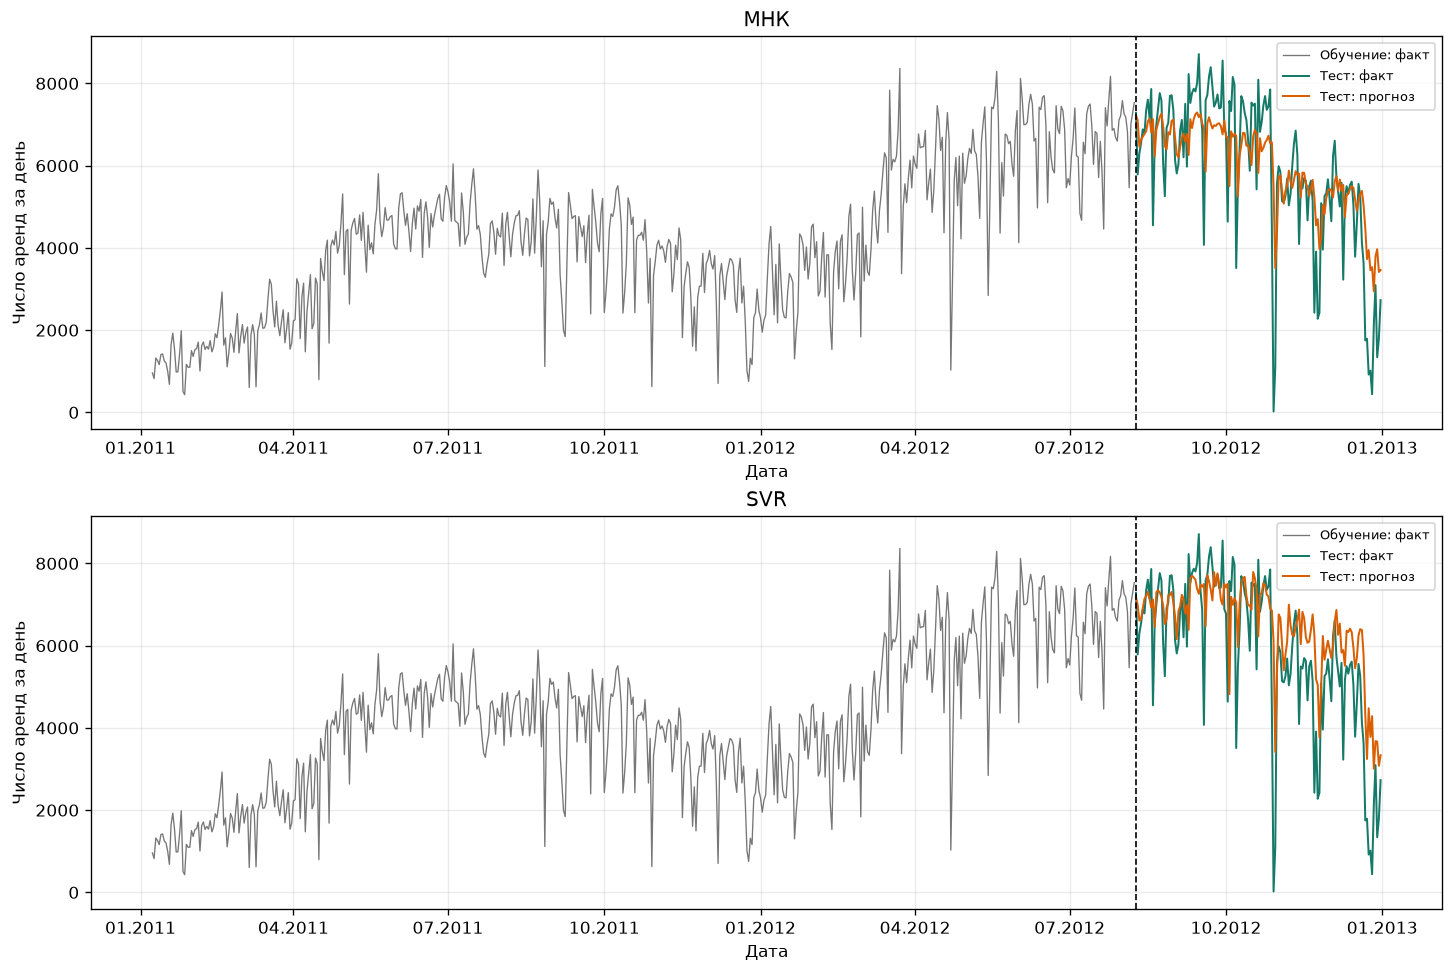

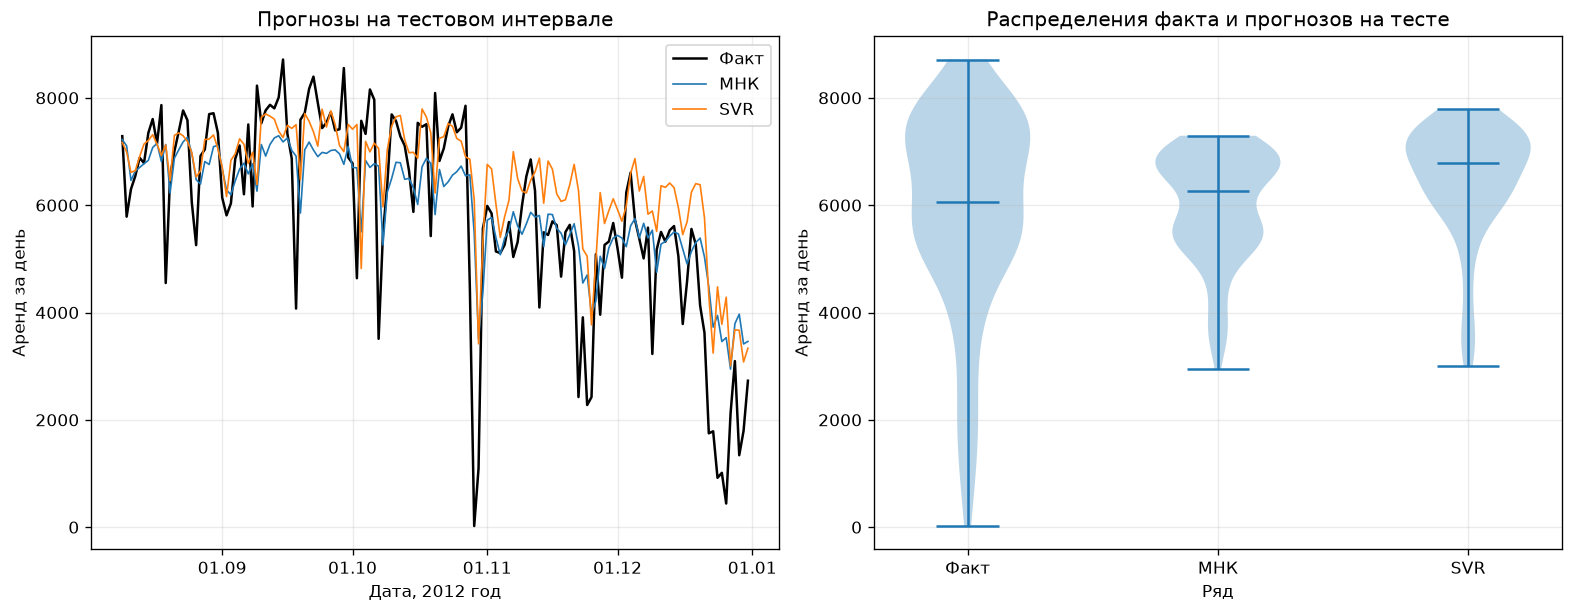

In [5]:
mase_scale = np.abs(np.diff(y_train)).mean()
assert mase_scale > 0
def regression_metrics(actual, predicted):
    return {'MAE': mean_absolute_error(actual, predicted),
            'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
            'MAPE, %': 100 * np.mean(np.abs(actual - predicted) / actual),
            'MASE': mean_absolute_error(actual, predicted) / mase_scale}

reg_table = pd.DataFrame({name: regression_metrics(y_test, values)
                          for name, values in reg_predictions.items()}).T
reg_table.loc['Наивный: как вчера'] = regression_metrics(y_test, X_test['rent_lag1'].to_numpy())
print(reg_table.round(3).to_string())
print(f'Знаменатель MASE, только по обучению: {mase_scale:.3f} аренды.')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), layout='constrained')
for ax, (name, predicted) in zip(axes, reg_predictions.items()):
    ax.plot(train['date'], y_train, color='#777777', linewidth=0.8, label='Обучение: факт')
    ax.plot(test['date'], y_test, color='#167a69', linewidth=1.2, label='Тест: факт')
    ax.plot(test['date'], predicted, color='#d95f02', linewidth=1.2, label='Тест: прогноз')
    ax.axvline(test['date'].iloc[0], color='black', linestyle='--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Число аренд за день')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m.%Y'))
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout='constrained')
axes[0].plot(test['date'], y_test, color='black', linewidth=1.5, label='Факт')
for name, values in reg_predictions.items():
    axes[0].plot(test['date'], values, linewidth=1, label=name)
axes[0].set_title('Прогнозы на тестовом интервале')
axes[0].set_xlabel('Дата, 2012 год')
axes[0].set_ylabel('Аренд за день')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
axes[0].legend()
axes[1].violinplot([y_test, *reg_predictions.values()], showmedians=True)
axes[1].set_xticks([1, 2, 3], ['Факт', *reg_predictions.keys()])
axes[1].set_title('Распределения факта и прогнозов на тесте')
axes[1].set_xlabel('Ряд')
axes[1].set_ylabel('Аренд за день')
for ax in axes: ax.grid(alpha=0.25)
plt.show()

## 5. Перевод в классификацию и баланс классов
Исходная граница — 4500 аренд: класс 1, если cnt >= 4500, иначе класс 0.
Это условная граница высокого спроса, а не доказанная граница прибыльности:
сведений о расходах и выручке в данных нет.
Для дополнительного эксперимента повышаем границу до 80-го процентиля обучающей цели.
Это создаёт дисбаланс около 80/20 на обучении без удаления или дублирования дней.
На тесте используем ту же обучающую границу; баланс теста не подгоняем.

Добавляем отдельные столбцы классов. Оцениваем доли во всём исходном файле,
обучении и тесте. Последние могут различаться из-за изменения спроса во времени.

        Сценарий  Граница   Выборка  Класс 0  Класс 1  Доля класса 1, %
Исходная граница   4500.0 Весь файл      359      372             50.89
Исходная граница   4500.0  Обучение      327      252             43.52
Исходная граница   4500.0      Тест       25      120             82.76
 Дисбаланс 80/20   5767.8 Весь файл      534      197             26.95
 Дисбаланс 80/20   5767.8  Обучение      463      116             20.03
 Дисбаланс 80/20   5767.8      Тест       64       81             55.86


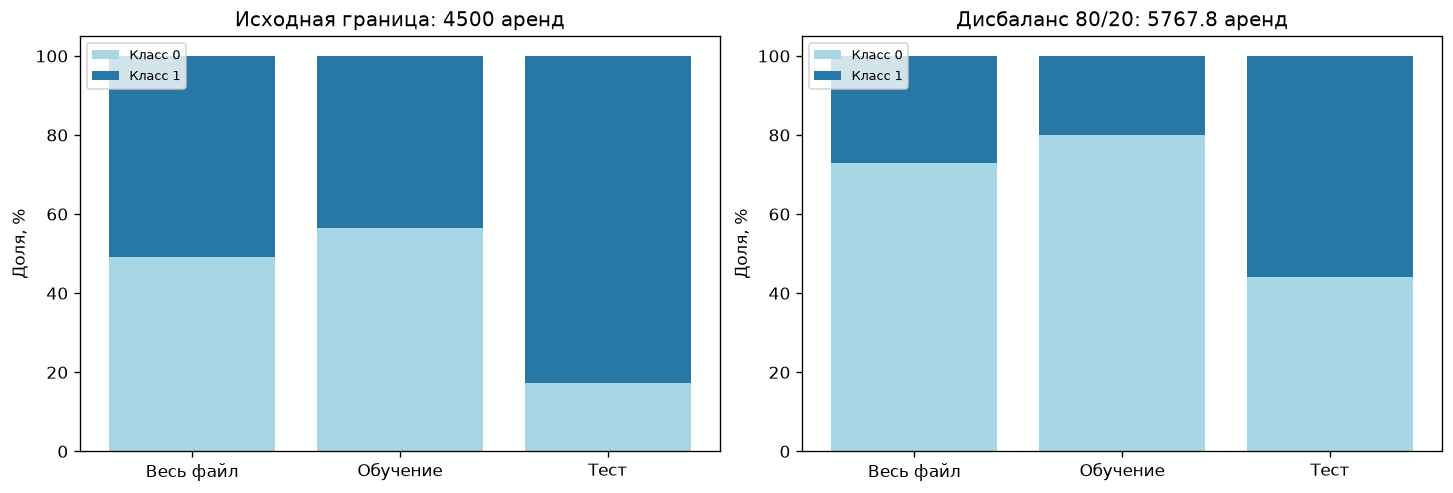

In [6]:
thresholds = {'Исходная граница': 4500.0, 'Дисбаланс 80/20': float(np.quantile(y_train, 0.8))}
balance_rows = []
for scenario, threshold in thresholds.items():
    raw[scenario] = (raw['cnt'] >= threshold).astype(int)
    frame[scenario] = (frame['target'] >= threshold).astype(int)
    for part, values in [('Весь файл', raw['cnt'].to_numpy()), ('Обучение', y_train), ('Тест', y_test)]:
        labels = (values >= threshold).astype(int)
        balance_rows.append({'Сценарий': scenario, 'Граница': threshold, 'Выборка': part,
                             'Класс 0': int((labels == 0).sum()), 'Класс 1': int(labels.sum()),
                             'Доля класса 1, %': 100 * labels.mean()})
balance_table = pd.DataFrame(balance_rows)
print(balance_table.round(2).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
for ax, (scenario, threshold) in zip(axes, thresholds.items()):
    rows = balance_table[balance_table['Сценарий'] == scenario]
    shares = rows['Доля класса 1, %'].to_numpy()
    ax.bar(rows['Выборка'], 100-shares, label='Класс 0', color='#a9d6e5')
    ax.bar(rows['Выборка'], shares, bottom=100-shares, label='Класс 1', color='#2878a5')
    ax.set_title(f'{scenario}: {threshold:g} аренд')
    ax.set_ylabel('Доля, %')
    ax.set_ylim(0, 105)
    ax.legend(loc='upper left', fontsize=8)
plt.show()

## 6. kNN, SVM и классификация по регрессии
Для каждого определения класса заново обучаем kNN и SVM. Число соседей k и
параметр SVM C выбираем по F1 на валидации, а не на тесте. F1 относится к классу 1.
Для kNN вероятность — доля соседей класса 1. Для SVM используем сигмоидальную
калибровку: внутри переданных обучающих данных первые 75% обучают SVM,
следующие 25% переводят её оценки в вероятности. Калибровочный блок всегда позже
обучающего, а внешняя валидация и тест — ещё позже. Это уменьшает число дней
для обучения самой SVM, но отделяет настройку вероятностей от подгонки границы.
Класс для обоих классификаторов определяем по вероятности >= 0,5.

У лучшей регрессии класс определяется напрямую: прогноз аренд >= границы.
Для ROC используем непрерывный прогноз. Для LogLoss нужна вероятность, поэтому
применяем нормальную модель ошибки: p = Φ((прогноз − граница) / s).
Масштаб s берём из RMSE выбранной регрессии на валидации, без тестовых ответов.
Это приближённая вероятностная интерпретация, а не доказанная калибровка.
При p=0,5 она сохраняет ту же границу, что и прямое сравнение прогноза с порогом.

In [7]:
def build_classifier(name, parameter, n_samples):
    if name == 'kNN':
        return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=parameter))
    cut = int(n_samples * 0.75)
    split = [(np.arange(cut), np.arange(cut, n_samples))]
    base = make_pipeline(StandardScaler(), SVC(C=parameter, kernel='rbf', gamma='scale'))
    return CalibratedClassifierCV(base, method='sigmoid', cv=split, ensemble=True)

probability_scale = float(np.sqrt(mean_squared_error(y_val, validation_predictions[best_reg_name])))
assert probability_scale > 0
all_scores, all_details, tuning_rows = [], {}, []
for scenario, threshold in thresholds.items():
    labels_fit, labels_val = (y_fit >= threshold).astype(int), (y_val >= threshold).astype(int)
    labels_train, labels_test = (y_train >= threshold).astype(int), (y_test >= threshold).astype(int)
    assert all(len(np.unique(a)) == 2 for a in [labels_fit, labels_val, labels_train, labels_test])
    details = {}
    for name, candidates in [('kNN', [5, 11, 21]), ('SVM', [0.1, 1, 10])]:
        trials = []
        for parameter in candidates:
            model = build_classifier(name, parameter, len(X_fit)).fit(X_fit, labels_fit)
            p_val = model.predict_proba(X_val)[:, 1]
            score = f1_score(labels_val, p_val >= 0.5, zero_division=0)
            trials.append((score, parameter))
        val_f1, parameter = max(trials, key=lambda pair: pair[0])
        model = build_classifier(name, parameter, len(X_train)).fit(X_train, labels_train)
        probabilities = model.predict_proba(X_test)[:, 1]
        details[name] = {'class': (probabilities >= 0.5).astype(int), 'probability': probabilities,
                         'score': probabilities, 'model': model}
        tuning_rows.append({'Сценарий': scenario, 'Модель': name, 'k или C': parameter, 'F1 валидации': val_f1})
    chosen_forecast = reg_predictions[best_reg_name]
    details[f'Порог по {best_reg_name}'] = {
        'class': (chosen_forecast >= threshold).astype(int),
        'probability': norm.cdf((chosen_forecast-threshold)/probability_scale), 'score': chosen_forecast}
    for name, item in details.items():
        p = np.clip(item['probability'], 1e-6, 1-1e-6)
        all_scores.append({'Сценарий': scenario, 'Модель': name,
                           'Accuracy': accuracy_score(labels_test, item['class']),
                           'F1': f1_score(labels_test, item['class'], zero_division=0),
                           'LogLoss': log_loss(labels_test, p, labels=[0, 1]),
                           'ROC AUC': roc_auc_score(labels_test, item['score'])})
    all_details[scenario] = {'truth': labels_test, 'predictions': details}
print(pd.DataFrame(tuning_rows).round(4).to_string(index=False))
class_table = pd.DataFrame(all_scores).set_index(['Сценарий', 'Модель'])
print('\nМетрики на тесте:')
print(class_table.round(4).to_string())
print(f'Масштаб ошибки для вероятностей регрессии: {probability_scale:.3f} аренды.')

        Сценарий Модель  k или C  F1 валидации
Исходная граница    kNN     21.0        0.9173
Исходная граница    SVM      0.1        0.9294
 Дисбаланс 80/20    kNN      5.0        0.1875
 Дисбаланс 80/20    SVM      0.1        0.0000

Метрики на тесте:
                               Accuracy      F1  LogLoss  ROC AUC
Сценарий         Модель                                          
Исходная граница kNN             0.7103  0.8000   0.5542   0.8607
                 SVM             0.8276  0.9057   0.4388   0.8613
                 Порог по МНК    0.8966  0.9402   0.2908   0.8747
Дисбаланс 80/20  kNN             0.8759  0.8902   0.6798   0.9228
                 SVM             0.5586  0.7168   0.7931   0.2479
                 Порог по МНК    0.8828  0.8982   0.3770   0.9263
Масштаб ошибки для вероятностей регрессии: 1067.039 аренды.


## 7. ROC-кривые и матрицы ошибок
Чем выше Accuracy, F1 и ROC AUC, тем лучше; для LogLoss лучше меньшее значение.
Accuracy сравниваем с простым выбором самого частого класса обучения.
В матрицах строки — реальные классы, столбцы — предсказанные; положительный класс — 1.
На ROC ось X — доля ложных срабатываний, ось Y — доля найденных дней класса 1.

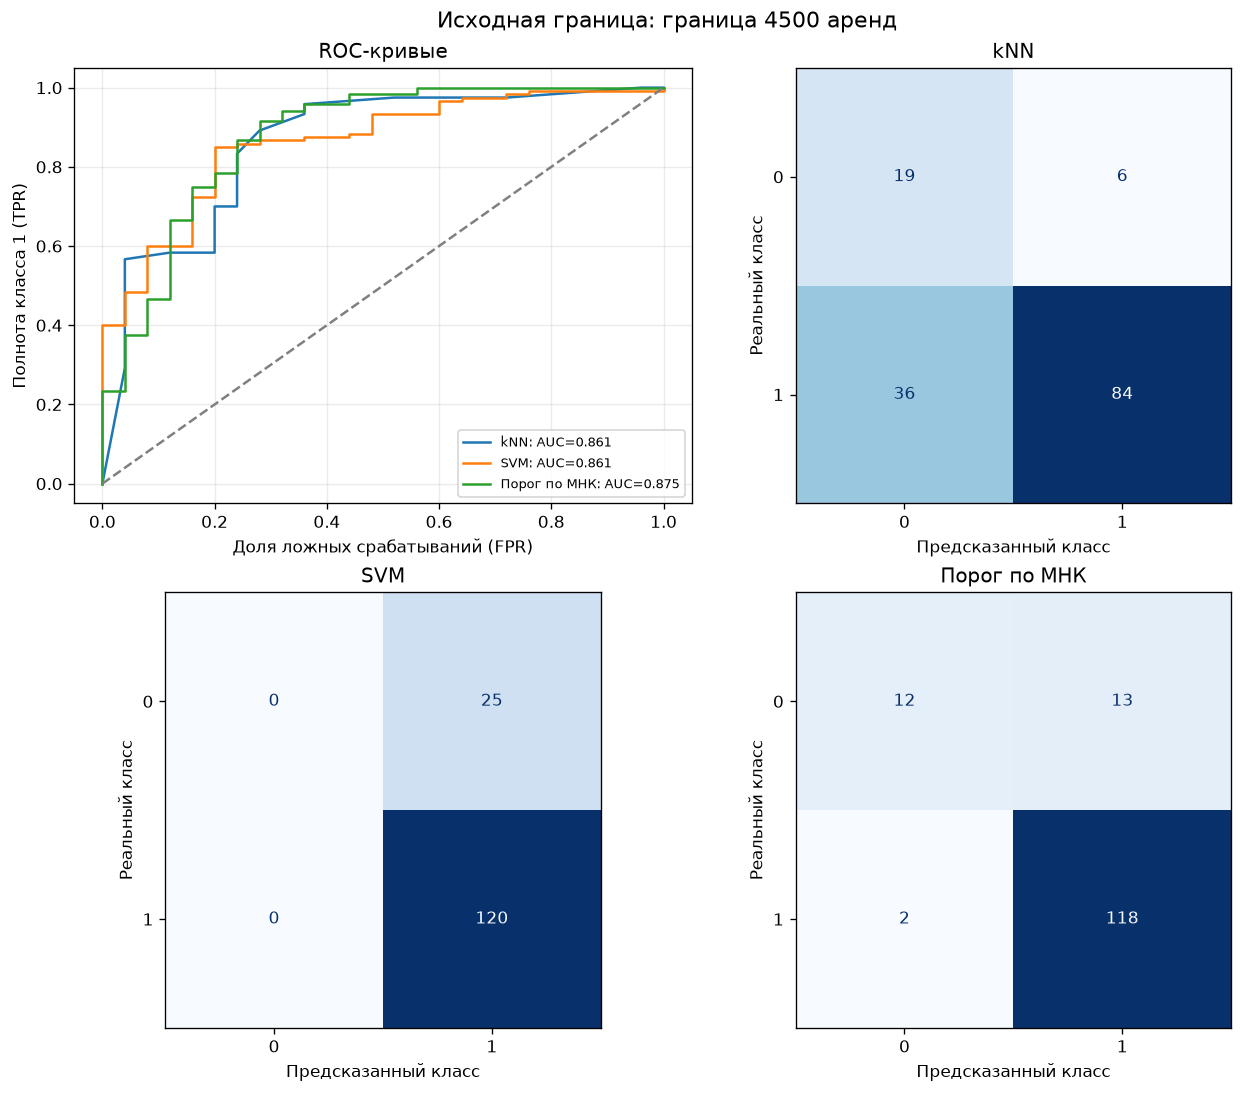

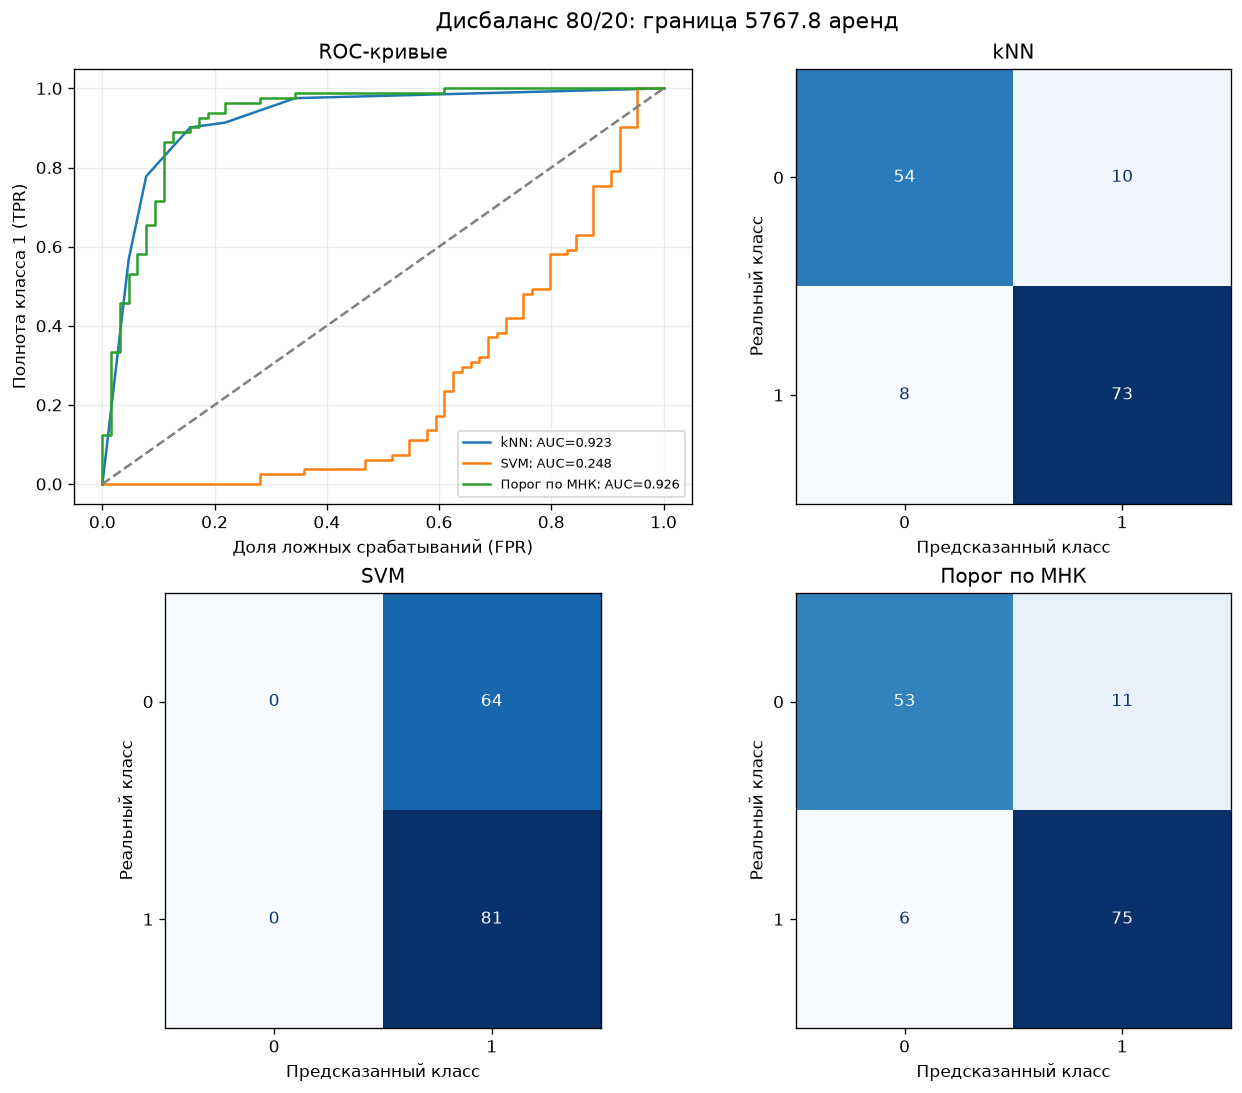

        Сценарий  Класс большинства обучения  Accuracy константы на тесте
Исходная граница                           0                       0.1724
 Дисбаланс 80/20                           0                       0.4414


In [8]:
baseline_rows = []
for scenario, result in all_details.items():
    truth = result['truth']
    threshold = thresholds[scenario]
    majority = int(np.mean(y_train >= threshold) >= 0.5)
    baseline_rows.append({'Сценарий': scenario, 'Класс большинства обучения': majority,
                          'Accuracy константы на тесте': np.mean(truth == majority)})
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), layout='constrained')
    roc_ax = axes[0, 0]
    for name, item in result['predictions'].items():
        fpr, tpr, _ = roc_curve(truth, item['score'])
        auc = roc_auc_score(truth, item['score'])
        roc_ax.plot(fpr, tpr, label=f'{name}: AUC={auc:.3f}')
    roc_ax.plot([0, 1], [0, 1], '--', color='gray')
    roc_ax.set(xlabel='Доля ложных срабатываний (FPR)', ylabel='Полнота класса 1 (TPR)', title='ROC-кривые')
    roc_ax.grid(alpha=0.25)
    roc_ax.legend(fontsize=8)
    for ax, (name, item) in zip(list(axes.flat)[1:], result['predictions'].items()):
        cm = confusion_matrix(truth, item['class'], labels=[0, 1])
        ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set(title=name, xlabel='Предсказанный класс', ylabel='Реальный класс')
    fig.suptitle(f'{scenario}: граница {threshold:g} аренд', fontsize=13)
    plt.show()
print(pd.DataFrame(baseline_rows).round(4).to_string(index=False))

## 8. Сравнение после изменения границы
Повышение границы изменяет сам смысл класса 1. Поэтому рост Accuracy или F1
нельзя автоматически приписывать улучшению алгоритма: теперь решается другая
задача. Набор признаков, тестовые даты и процедура подбора настроек остаются одинаковыми.
Пропорция 80/20 задаётся по обучению; такая же доля в будущем не гарантируется.

Изменение метрик: новая граница минус исходная
              Accuracy      F1  LogLoss  ROC AUC
Модель                                          
kNN             0.1655  0.0902   0.1256   0.0622
SVM            -0.2690 -0.1888   0.3543  -0.6135
Порог по МНК   -0.0138 -0.0420   0.0862   0.0516


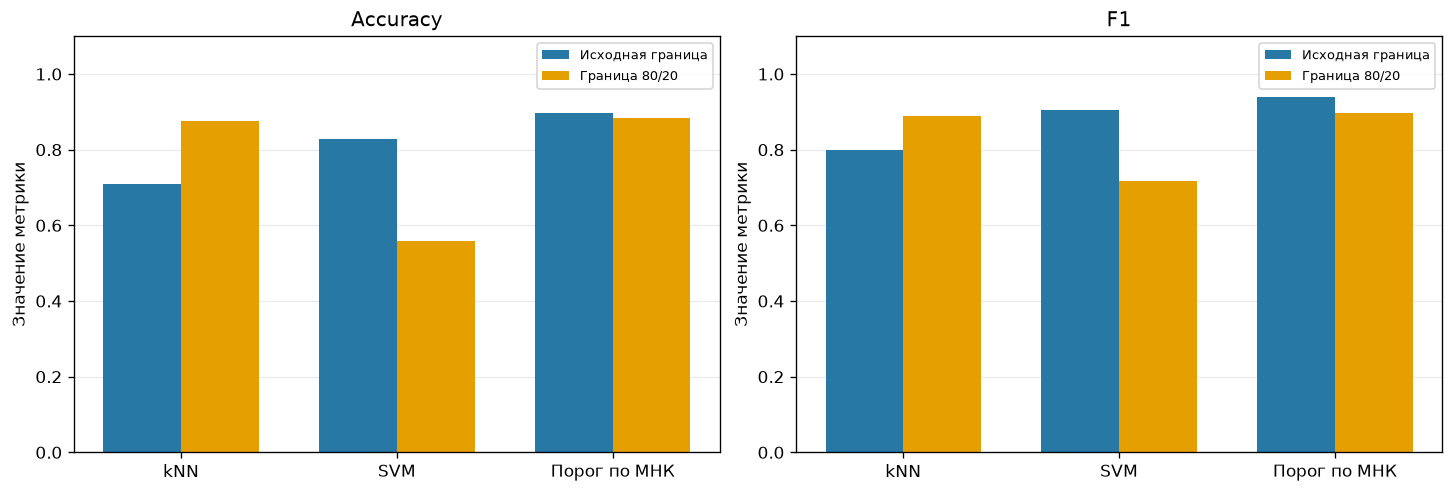

In [9]:
before = class_table.loc['Исходная граница']
after = class_table.loc['Дисбаланс 80/20']
delta = after - before
print('Изменение метрик: новая граница минус исходная')
print(delta.round(4).to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
for ax, metric in zip(axes, ['Accuracy', 'F1']):
    x = np.arange(len(before))
    ax.bar(x-0.18, before[metric], width=0.36, label='Исходная граница', color='#2878a5')
    ax.bar(x+0.18, after.loc[before.index, metric], width=0.36, label='Граница 80/20', color='#e69f00')
    ax.set_xticks(x, before.index)
    ax.set_ylim(0, 1.1)
    ax.set_title(metric)
    ax.set_ylabel('Значение метрики')
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8)
plt.show()

## Выводы
**Регрессия.** На валидации выбран МНК: RMSE 1067,039 против 1267,827 у лучшего
варианта SVR. На тесте МНК также лучше SVR по всем четырём метрикам:
MAE 875,357, RMSE 1223,236, MAPE 198,716%, MASE 1,257.
Прогноз «как вчера» имеет RMSE 1290,766: МНК улучшает её примерно на 5,2%,
но выигрыш по MAE небольшой. MASE > 1 показывает, что ошибка превышает среднее
суточное изменение на обучении. Это не противоречит небольшому преимуществу
над наивным прогнозом на тесте: масштабы этих двух интервалов различаются.

По графикам обе регрессии передают общий осенне-зимний спад, но сглаживают
резкие падения. Скрипичные диаграммы показывают более узкий разброс прогнозов,
особенно МНК. MAPE сильно увеличивается на днях с очень малым спросом:
29 октября 2012 года зарегистрировано всего 22 аренды. Даже умеренная абсолютная
ошибка даёт в такой день огромную относительную ошибку. Значение сохранено,
MAPE рассчитана по всем дням; результаты нельзя называть высокоточными.

**Исходная классификация.** При границе 4500 аренд порог по МНК даёт лучшие
тестовые результаты среди трёх подходов: Accuracy 0,897, F1 0,940,
LogLoss 0,291 и ROC AUC 0,875. Из 145 дней верно классифицировано 130:
TN=12, FP=13, FN=2, TP=118. Метод хорошо находит дни высокого спроса,
но ошибочно относит к ним 13 из 25 дней низкого спроса.
У SVM Accuracy 0,828 выглядит высокой, однако матрица ошибок показывает,
что при вероятностном пороге 0,5 она относит все дни к классу 1.
Поэтому одной Accuracy недостаточно. Непрерывные оценки всё же различаются,
и ROC AUC 0,861 показывает полезное ранжирование до выбора порога.

**Изменение баланса.** Повышение границы до 5767,8 аренд меняет долю класса 1
в исходном файле с 50,89% до 26,95%, а в обучении — с 43,52% до 20,03%.
На тесте она составляет 55,86%, то есть соотношение 80/20 не переносится
автоматически в будущее. Это связано с временными изменениями спроса.
kNN после изменения границы достигает Accuracy 0,876 и F1 0,890,
но LogLoss ухудшается с 0,554 до 0,680: правильных классов стало больше,
однако ошибки вероятностей остались существенными.
Порог по МНК даёт Accuracy 0,883 и F1 0,898: лучший итоговый результат
и при новой границе, хотя по этим двум метрикам он ниже исходного.

SVM при новой границе снова предсказывает только класс 1, а её ROC AUC
падает до 0,248. При хронологической калибровке в части, обучающей саму SVM,
для нового высокого порога есть лишь 7 положительных примеров, тогда как
в следующем калибровочном блоке их уже 109. Такая смена распределения делает
выбранную схему SVM ненадёжной на этом разбиении. Низкое качество сохранено
в результатах, а не исправлено настройкой по тестовым ответам.

Для выбранных данных предпочтителен МНК с последующим порогом: он сохраняет
информацию о величине спроса и устойчивее показал себя в обоих сценариях.
Однако оценка основана на одном временном тестовом интервале. Изменение порога
меняет саму задачу; разницу метрик нельзя считать чистым эффектом дисбаланса.